[download this notebook here](https://github.com/HumanCompatibleAI/imitation/blob/master/docs/tutorials/10_train_custom_env.ipynb)
# Train Behavior Cloning in a Custom Environment

You can use `imitation` to train a policy (and, for many imitation learning algorithm, learn rewards) in a custom environment.




## Step 1: Define the environment

We will use a simple ObservationMatching environment as an example. The premise is simple -- the agent receives a vector of observations, and must output a vector of actions that matches the observations as closely as possible.

If you have your own environment that you'd like to use, you can replace the code below with your own environment. Make sure it complies with the standard Gym API, and that the observation and action spaces are specified correctly.

In [2]:
from typing import Dict, Optional
from typing import Any
import numpy as np
import gymnasium as gym
import matplotlib
# matplotlib.use("QtAgg", force=True)
import matplotlib.pyplot as plt
# %matplotlib ipympl
# from PyQt6 import QtWidgets
%matplotlib ipympl
from gymnasium.spaces import Box


class CircleForceEnv(gym.Env):
    """
    2D continuous environment: circle controlled by forces.
    State: [x, y, vx, vy]; Action: [fx, fy].
    Contains both binary RL reward (in step) and a smooth continuous cost.
    Optionally visualizes multiple trajectories, each in its own color.
    Uses PyQt6 for event loop pumping.
    """

    metadata = {"render_modes": ["human"], "render_fps": 30}

    def __init__(
        self,
        width=10.0,
        height=10.0,
        penalty_zones=None,
        goal_region=None,
        mass=1.0,
        dt=0.1,
        energy_coeff=0.01,
        time_penalty=0.1,
        initial_state=None,
        visualize=False,
        render_mode=None,
    ):
        super().__init__()
        # environment parameters
        self.width = width
        self.height = height
        self.mass = mass
        self.dt = dt
        self.energy_coeff = energy_coeff
        self.time_penalty = time_penalty
        self.penalty_zones = penalty_zones or []
        self.goal_region = goal_region

        # initial state handling
        default_state = np.array([1.0, self.height - 1.0, 0.0, 0.0], dtype=np.float32)
        if initial_state is None:
            self.initial_state = default_state
        else:
            self.initial_state = np.array(initial_state, dtype=np.float32)

        # action & observation spaces
        self.action_space = Box(low=-1.0, high=1.0, shape=(2,), dtype=np.float32)
        high = np.array([width, height, np.inf, np.inf], dtype=np.float32)
        self.observation_space = Box(low=-high, high=high, dtype=np.float32)

        # visualization flags and storage
        self.visualize = visualize
        self.render_mode = render_mode
        self._episodes = []  # list of dicts: {'line': Line2D, 'positions': [pts]}

        if self.visualize and self.render_mode in ["human", "episode"]:
            # set up QApplication for PyQt6
            # self._app = QtWidgets.QApplication.instance() or QtWidgets.QApplication(
            #     sys.argv
            # )
            # initialize Matplotlib figure
            # plt.ion()
            self._fig, self._ax = plt.subplots()
            self._ax.set_xlim(0, self.width)
            self._ax.set_ylim(0, self.height)
            self._ax.set_aspect("equal")

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        # initialize to the preset initial state
        self.state = self.initial_state.copy()

        if self.visualize:
            if self.render_mode == "episode" and len(self._episodes) > 0:
                self.render()
            # start a new trajectory: create line and position buffer
            self.plot_color = np.random.rand(
                3,
            )
            (line,) = self._ax.plot([], [], color=self.plot_color)
            ep = {"line": line, "positions": [self.state[:2].copy()]}
            self._episodes.append(ep)

        return self.state.copy(), {}

    def _step(self, action, do_render, append_to_episode):
        # physics update internal method
        pos, vel = self.state[:2], self.state[2:]
        force = np.clip(action, self.action_space.low, self.action_space.high)
        accel = force / self.mass
        new_vel = vel + accel * self.dt
        new_pos = pos + new_vel * self.dt
        self.state = np.concatenate([new_pos, new_vel])

        # reward computation
        r = 0.0
        for center, radius, penalty in self.penalty_zones:
            if np.linalg.norm(new_pos - center) <= radius:
                r -= penalty
        if self.goal_region:
            c, rad, rew = self.goal_region
            if np.linalg.norm(new_pos - c) <= rad:
                r += rew
        r -= self.energy_coeff * np.dot(force, force)
        r -= self.time_penalty

        # termination
        done = False
        if not (0 <= new_pos[0] <= self.width and 0 <= new_pos[1] <= self.height):
            done = True
        if (
            self.goal_region
            and np.linalg.norm(new_pos - self.goal_region[0]) <= self.goal_region[1]
        ):
            done = True

        # update only positions; defer plotting to render()
        if append_to_episode:
            self._episodes[-1]["positions"].append(new_pos.copy())

        if do_render:
            self.render()

        return self.state.copy(), r, done, False, {}

    def step_no_visualize(self, action):
        """Convenience method for step without visualization."""
        # physics update
        return self._step(action, do_render=False, append_to_episode=False)

    def step(self, action):
        return self._step(
            action,
            do_render=self.render_mode == "human",
            append_to_episode=self.visualize,
        )

    def render(self):
        # conforms to Gymnasium API; updates the latest trajectory
        if not (self.visualize and self.render_mode in ["human", "episode"]):
            return None
        ep = self._episodes[-1]
        xs, ys = zip(*ep["positions"])
        ep["line"].set_data(xs, ys)
        self._ax.set_title(f"Episode {len(self._episodes)} Step {len(xs) - 1}")
        self._fig.canvas.draw()
        self._fig.canvas.flush_events()
        plt.pause(1 / self.metadata["render_fps"])
        # process Qt events to keep window responsive
        # self._app.processEvents()

    def close(self):
        if self.visualize and self.render_mode == "human":
            plt.ioff()
            plt.close(self._fig)
            # exit Qt loop if necessary
            # self._app.quit()


## Step 2: create the environment

From here, we have two options:
- Add the environment to the gym registry, and use it with existing utilities (e.g. `make`)
- Use the environment directly

You only need to execute the cells in step 2a, or step 2b to proceed.

At the end of these steps, we want to have:
- `env`: a single environment that we can use for training an expert with SB3
- `venv`: a vectorized environment where each individual environment is wrapped in `RolloutInfoWrapper`, that we can use for collecting rollouts with `imitation`

### Step 2a (recommended): add the environment to the gym registry

The standard approach is adding the environment to the gym registry.

In [6]:
gym.register(
    id="custom/CircleForce-v0",
    entry_point=CircleForceEnv,  # This can also be the path to the class, e.g. `observation_matching:ObservationMatchingEnv`
    max_episode_steps=500,
)

After registering, you can create an environment is `gym.make(env_id)` which automatically handles the `TimeLimit` wrapper.

To create a vectorized env, you can use the `make_vec_env` helper function (Option A), or create it directly (Options B1 and B2)

In [7]:
from gymnasium.wrappers import TimeLimit
from imitation.data import rollout
from imitation.data.wrappers import RolloutInfoWrapper
from imitation.util.util import make_vec_env
from stable_baselines3.common.vec_env import DummyVecEnv, SubprocVecEnv

# Create a single environment for training an expert with SB3
env = gym.make("custom/CircleForce-v0")


# Create a vectorized environment for training with `imitation`

# Option A: use the `make_vec_env` helper function - make sure to pass `post_wrappers=[lambda env, _: RolloutInfoWrapper(env)]`
venv = make_vec_env(
    "custom/CircleForce-v0",
    rng=np.random.default_rng(),
    n_envs=4,
    post_wrappers=[lambda env, _: RolloutInfoWrapper(env)],
)


# Option B1: use a custom env creator, and create VecEnv directly
# def _make_env():
#     """Helper function to create a single environment. Put any logic here, but make sure to return a RolloutInfoWrapper."""
#     _env = gym.make("custom/ObservationMatching-v0")
#     _env = RolloutInfoWrapper(_env)
#     return _env
#
# venv = DummyVecEnv([_make_env for _ in range(4)])
#
# # Option B2: we can also use a parallel VecEnv implementation
# venv = SubprocVecEnv([_make_env for _ in range(4)])

In [43]:
expert

In [8]:
env

<TimeLimit<OrderEnforcing<PassiveEnvChecker<CircleForceEnv<custom/CircleForce-v0>>>>>

In [9]:
venv

## Gather non-expert trajectories

In [47]:
from stable_baselines3 import PPO
from stable_baselines3.ppo import MlpPolicy
from stable_baselines3.common.evaluation import evaluate_policy
from gymnasium.wrappers import TimeLimit

In [44]:
expert = PPO(
    policy=MlpPolicy,
    env=env,
    seed=0,
    batch_size=64,
    ent_coef=0.0,
    learning_rate=0.0003,
    n_epochs=10,
    n_steps=64,
)

In [45]:
rng = np.random.default_rng()
rollouts0 = rollout.rollout(
    expert,
    venv,
    rollout.make_sample_until(min_timesteps=None, min_episodes=50),
    rng=rng,
)
transitions0 = rollout.flatten_trajectories(rollouts0)

## Step 3: Training

And now we're just about done! Whether you used step 2a or 2b, your environment should now be ready to use with SB3 and `imitation`.

For the sake of completeness, we'll train a BC model, the same way as in the first tutorial, but with our custom environment.

Keep in mind that while we're using BC in this tutorial, you can just as easily use any of the other algorithms with the environment prepared in this way.

In [46]:
reward, _ = evaluate_policy(expert, env, 10)
print(f"Reward before training: {reward}")

expert.learn(10_000)  # Note: set to 100000 to train a proficient expert
reward, _ = evaluate_policy(expert, expert.get_env(), 10)
print(f"Expert reward: {reward}")

Reward before training: -50.00002207607031
Expert reward: -1.544449


In [23]:
rng = np.random.default_rng()
rollouts = rollout.rollout(
    expert,
    venv,
    rollout.make_sample_until(min_timesteps=None, min_episodes=50),
    rng=rng,
)
transitions = rollout.flatten_trajectories(rollouts)

In [24]:
len(rollouts)

52

In [25]:
rollouts[0]

TrajectoryWithRew(obs=array([[ 1.0000000e+00,  9.0000000e+00,  0.0000000e+00,  0.0000000e+00],
       [ 9.9000001e-01,  9.0021372e+00, -1.0000000e-01,  2.1374015e-02],
       [ 9.7000003e-01,  9.0019855e+00, -2.0000000e-01, -1.5171617e-03],
       [ 9.4000006e-01,  9.0004759e+00, -3.0000001e-01, -1.5095835e-02],
       [ 9.0000004e-01,  8.9979544e+00, -4.0000001e-01, -2.5213290e-02],
       [ 8.5000002e-01,  8.9978065e+00, -5.0000000e-01, -1.4778599e-03],
       [ 7.9000002e-01,  8.9954777e+00, -6.0000002e-01, -2.3285812e-02],
       [ 7.2000003e-01,  8.9914417e+00, -7.0000005e-01, -4.0358588e-02],
       [ 6.4000005e-01,  8.9869757e+00, -8.0000007e-01, -4.4656795e-02],
       [ 5.5000001e-01,  8.9823685e+00, -9.0000010e-01, -4.6075433e-02],
       [ 4.4999999e-01,  8.9766321e+00, -1.0000001e+00, -5.7361122e-02],
       [ 3.3999997e-01,  8.9687843e+00, -1.1000001e+00, -7.8478485e-02],
       [ 2.1999995e-01,  8.9601507e+00, -1.2000002e+00, -8.6335704e-02],
       [ 8.9999929e-02,  8.95

In [26]:
env.initial_state

array([1., 9., 0., 0.], dtype=float32)

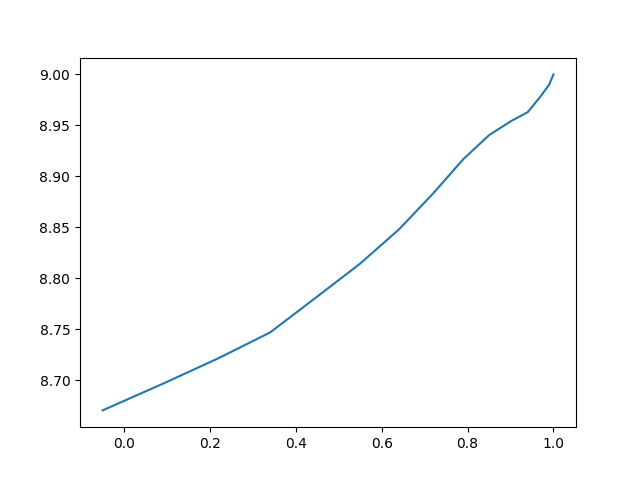

In [27]:
fig, ax = plt.subplots()
obs0 = rollouts0[0].obs
ax.plot(obs0[:,0], obs0[:,1])

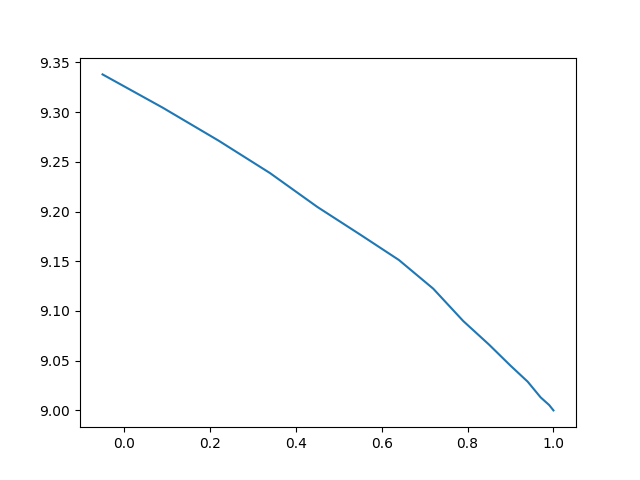

In [15]:
fig, ax = plt.subplots()
obs0 = rollouts[0].obs
ax.plot(obs0[:,0], obs0[:,1])

In [31]:
dir(transitions)

['__abstractmethods__',
 '__add__',
 '__annotations__',
 '__class__',
 '__class_getitem__',
 '__contains__',
 '__dataclass_fields__',
 '__dataclass_params__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__iter__',
 '__le__',
 '__len__',
 '__lt__',
 '__match_args__',
 '__module__',
 '__ne__',
 '__new__',
 '__orig_bases__',
 '__parameters__',
 '__post_init__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__reversed__',
 '__setattr__',
 '__sizeof__',
 '__slots__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abc_impl',
 '_is_protocol',
 'acts',
 'count',
 'dones',
 'index',
 'infos',
 'next_obs',
 'obs']

In [36]:
transitions.infos.shape

(728,)

In [42]:
transitions.acts

array([[-1.        ,  0.21374014],
       [-1.        , -0.22891176],
       [-1.        , -0.13578673],
       ...,
       [-1.        ,  0.18841769],
       [-1.        ,  0.0075966 ],
       [-1.        , -0.26239473]], shape=(728, 2), dtype=float32)

In [ ]:
from imitation.algorithms import bc

bc_trainer = bc.BC(
    observation_space=env.observation_space,
    action_space=env.action_space,
    demonstrations=transitions,
    rng=rng,
)

As before, the untrained policy only gets poor rewards:

In [ ]:
reward_before_training, _ = evaluate_policy(bc_trainer.policy, env, 10)
print(f"Reward before training: {reward_before_training}")

After training, we can get much closer to the expert's performance:

In [ ]:
bc_trainer.train(n_epochs=1)
reward_after_training, _ = evaluate_policy(bc_trainer.policy, env, 10)
print(f"Reward after training: {reward_after_training}")